TITANIC SURVIVAL CLASSIFICATION PROJECT

📊 STEP 1: LOADING AND EXPLORING DATA
--------------------------------------------------
✅ Datasets loaded successfully!
   Training set: (891, 12) (rows x columns)
   Test set: (418, 11)

📈 TRAINING DATA OVERVIEW:
First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked 

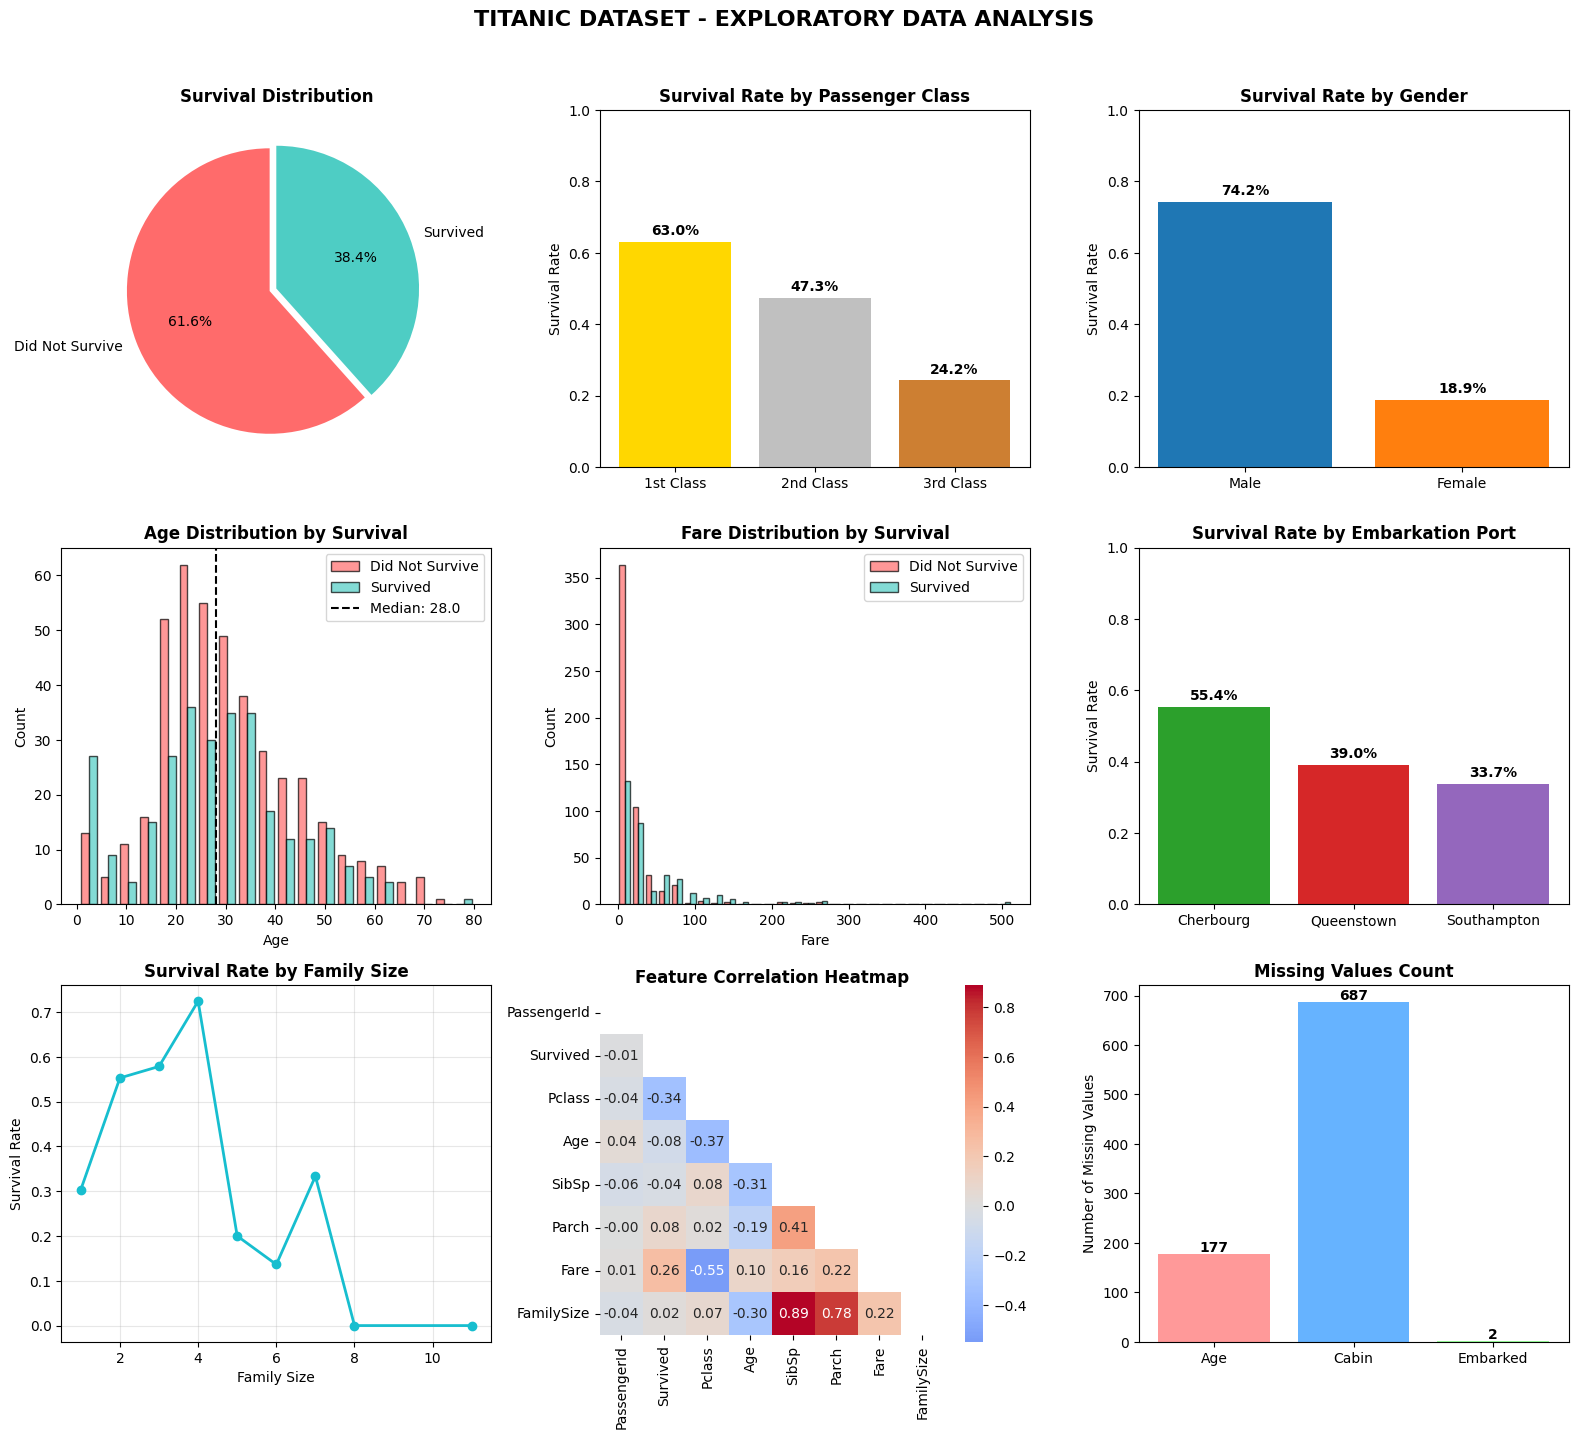



🧹 STEP 3: DATA CLEANING AND PREPROCESSING
--------------------------------------------------
🔧 Preprocessing training data...
   Processing training data...
🔧 Preprocessing test data...
   Processing test data...
✅ Data preprocessing completed!

📊 Cleaned training data shape: (891, 15)
📊 Cleaned test data shape: (418, 14)

🔍 CLEANED DATA INFO:
Columns: ['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'HasCabin', 'IsAlone', 'Title', 'AgeGroup', 'FareGroup']

Missing values after cleaning:
Series([], dtype: int64)


🎯 STEP 4: FEATURE SELECTION AND PREPARATION
--------------------------------------------------
📈 Selected 10 features for modeling:
    1. Pclass
    2. Sex
    3. Age
    4. Fare
    5. Embarked
    6. FamilySize
    7. IsAlone
    8. Title
    9. AgeGroup
   10. HasCabin

📊 Data shapes:
   X (features): (891, 10)
   y (target): (891,)
   X_test_final: (418, 10)


📊 STEP 5: TRAIN-VALIDATION SPLIT
----------------------

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

✅ Hyperparameter tuning complete!
   Best parameters: {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
   Best cross-validation score: 0.8273

🎯 TUNED MODEL PERFORMANCE:
   Accuracy:  0.8156
   Precision: 0.7903
   Recall:    0.7101
   F1-Score:  0.7481
   ROC-AUC:   0.8617


📈 STEP 9: MODEL EVALUATION VISUALIZATION
--------------------------------------------------


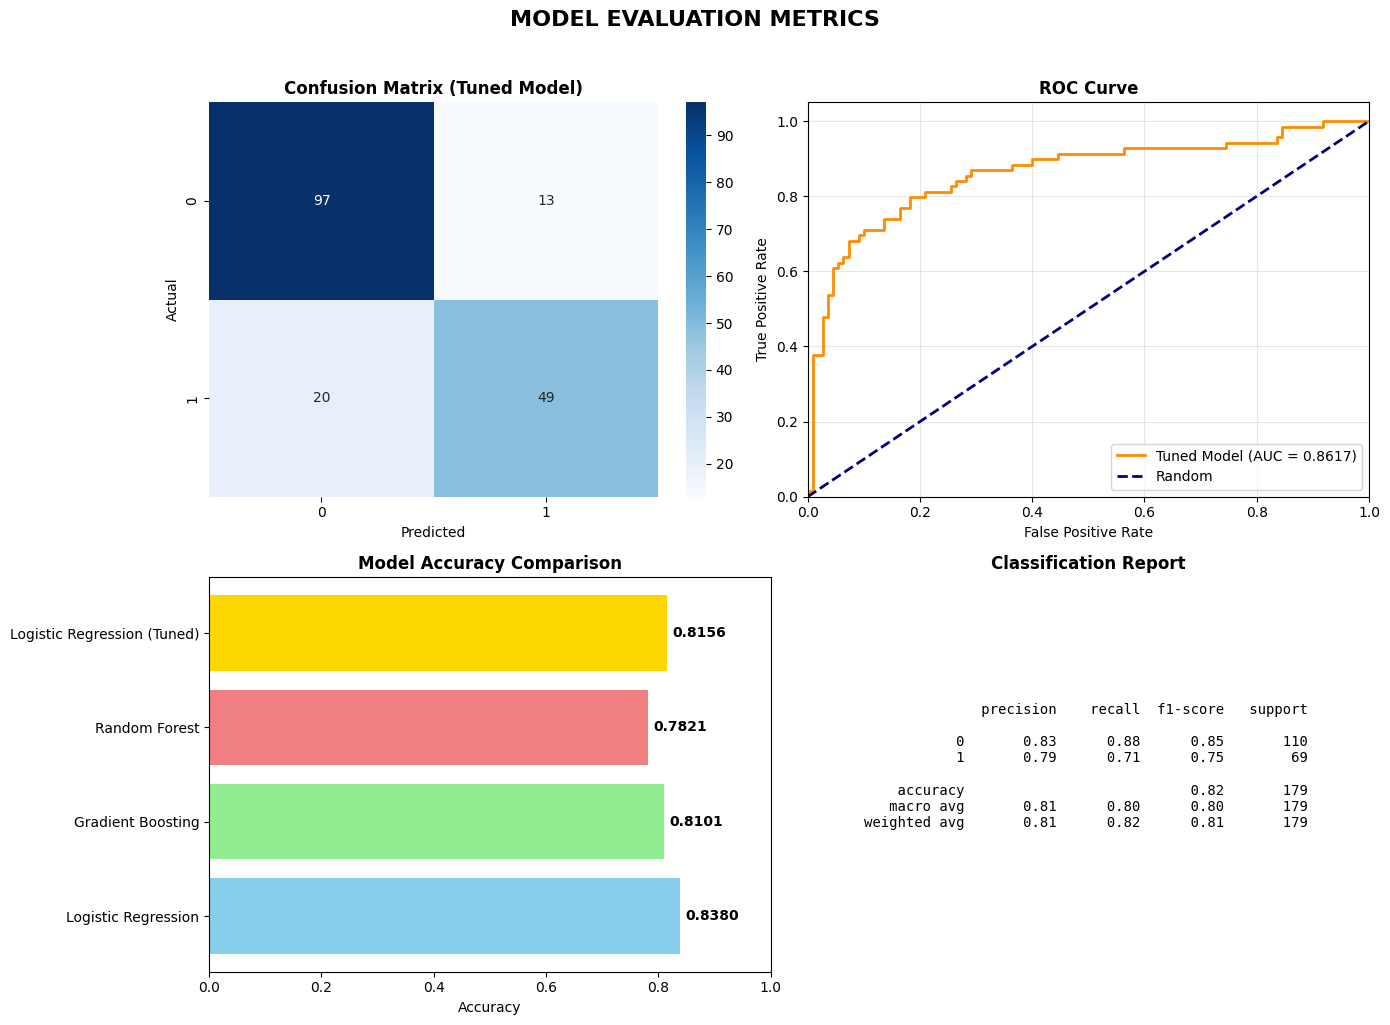



🚀 STEP 10: FINAL PREDICTIONS AND SUBMISSION
--------------------------------------------------
Training final model on entire training dataset...
Making predictions on test dataset...
✅ Submission file created: titanic_submission.csv

📊 Predicted survival rate in test set: 38.04%

📝 SAMPLE PREDICTIONS (First 10 passengers):
   Passenger  892: Did not survive
   Passenger  893: Survived
   Passenger  894: Did not survive
   Passenger  895: Did not survive
   Passenger  896: Survived
   Passenger  897: Did not survive
   Passenger  898: Survived
   Passenger  899: Did not survive
   Passenger  900: Survived
   Passenger  901: Did not survive


🔑 STEP 11: KEY INSIGHTS AND CONCLUSION

📊 KEY FINDINGS FROM THE ANALYSIS:
1. Survival Rates by Category:
   • Overall survival rate: 38.38%
   • Female survival rate: 74.20%
   • Male survival rate: 18.89%
   • 1st Class survival rate: 62.96%
   • 3rd Class survival rate: 24.24%

2. Most Important Factors for Survival:
   • Gender (females had mu

In [12]:
# ========== TITANIC SURVIVAL CLASSIFICATION - COMPLETE SOLUTION ==========
# Task: Build ML model to predict passenger survival based on age, gender, class, fare

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("TITANIC SURVIVAL CLASSIFICATION PROJECT")
print("="*70)

# ========== 1. LOAD AND EXPLORE DATA ==========
print("\n📊 STEP 1: LOADING AND EXPLORING DATA")
print("-"*50)

# Load the datasets
train = pd.read_csv('/kaggle/input/titanic/train.csv')
test = pd.read_csv('/kaggle/input/titanic/test.csv')
print(f"✅ Datasets loaded successfully!")
print(f"   Training set: {train.shape} (rows x columns)")
print(f"   Test set: {test.shape}")

# Display basic information
print("\n📈 TRAINING DATA OVERVIEW:")
print("First 5 rows:")
print(train.head())

print("\n🔍 DATASET INFORMATION:")
print(train.info())

print("\n📊 SUMMARY STATISTICS:")
print(train.describe())

print("\n❓ MISSING VALUES:")
missing_values = train.isnull().sum()
print(missing_values[missing_values > 0])

print("\n🎯 TARGET DISTRIBUTION (Survived):")
survival_counts = train['Survived'].value_counts()
survival_percent = train['Survived'].value_counts(normalize=True) * 100
print(f"   Did not survive (0): {survival_counts[0]:>4} ({survival_percent[0]:.1f}%)")
print(f"   Survived (1):       {survival_counts[1]:>4} ({survival_percent[1]:.1f}%)")

# ========== 2. EXPLORATORY DATA ANALYSIS ==========
print("\n\n📊 STEP 2: EXPLORATORY DATA ANALYSIS (EDA)")
print("-"*50)

# Create comprehensive visualizations
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle('TITANIC DATASET - EXPLORATORY DATA ANALYSIS', fontsize=16, fontweight='bold', y=1.02)

# Plot 1: Survival Distribution
colors = ['#ff6b6b', '#4ecdc4']
axes[0, 0].pie(survival_counts.values, labels=['Did Not Survive', 'Survived'], 
               autopct='%1.1f%%', startangle=90, colors=colors, explode=(0.05, 0))
axes[0, 0].set_title('Survival Distribution', fontweight='bold')

# Plot 2: Survival by Passenger Class
survival_by_class = train.groupby('Pclass')['Survived'].mean()
bars1 = axes[0, 1].bar(['1st Class', '2nd Class', '3rd Class'], survival_by_class.values,
                      color=['gold', 'silver', '#cd7f32'])
axes[0, 1].set_title('Survival Rate by Passenger Class', fontweight='bold')
axes[0, 1].set_ylabel('Survival Rate')
axes[0, 1].set_ylim(0, 1)
for bar, value in zip(bars1, survival_by_class.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, value + 0.02, 
                   f'{value:.1%}', ha='center', fontweight='bold')

# Plot 3: Survival by Gender
survival_by_gender = train.groupby('Sex')['Survived'].mean()
bars2 = axes[0, 2].bar(['Male', 'Female'], survival_by_gender.values,
                      color=['#1f77b4', '#ff7f0e'])
axes[0, 2].set_title('Survival Rate by Gender', fontweight='bold')
axes[0, 2].set_ylabel('Survival Rate')
axes[0, 2].set_ylim(0, 1)
for bar, value in zip(bars2, survival_by_gender.values):
    axes[0, 2].text(bar.get_x() + bar.get_width()/2, value + 0.02, 
                   f'{value:.1%}', ha='center', fontweight='bold')

# Plot 4: Age Distribution by Survival
survived_age = train[train['Survived'] == 1]['Age'].dropna()
not_survived_age = train[train['Survived'] == 0]['Age'].dropna()
axes[1, 0].hist([not_survived_age, survived_age], bins=20, 
                label=['Did Not Survive', 'Survived'], 
                color=['#ff6b6b', '#4ecdc4'], alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Age Distribution by Survival', fontweight='bold')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()
axes[1, 0].axvline(train['Age'].median(), color='black', linestyle='--', 
                  label=f"Median: {train['Age'].median():.1f}")
axes[1, 0].legend()

# Plot 5: Fare Distribution by Survival
survived_fare = train[train['Survived'] == 1]['Fare'].dropna()
not_survived_fare = train[train['Survived'] == 0]['Fare'].dropna()
axes[1, 1].hist([not_survived_fare, survived_fare], bins=30, 
                label=['Did Not Survive', 'Survived'], 
                color=['#ff6b6b', '#4ecdc4'], alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Fare Distribution by Survival', fontweight='bold')
axes[1, 1].set_xlabel('Fare')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()

# Plot 6: Survival by Embarkation Port
if 'Embarked' in train.columns:
    embarked_data = train.dropna(subset=['Embarked'])
    survival_by_embarked = embarked_data.groupby('Embarked')['Survived'].mean()
    ports = ['Cherbourg', 'Queenstown', 'Southampton']
    bars3 = axes[1, 2].bar(ports, survival_by_embarked.values, 
                          color=['#2ca02c', '#d62728', '#9467bd'])
    axes[1, 2].set_title('Survival Rate by Embarkation Port', fontweight='bold')
    axes[1, 2].set_ylabel('Survival Rate')
    axes[1, 2].set_ylim(0, 1)
    for bar, value in zip(bars3, survival_by_embarked.values):
        axes[1, 2].text(bar.get_x() + bar.get_width()/2, value + 0.02, 
                       f'{value:.1%}', ha='center', fontweight='bold')

# Plot 7: Family Size Analysis
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
family_survival = train.groupby('FamilySize')['Survived'].mean()
axes[2, 0].plot(family_survival.index, family_survival.values, marker='o', 
               linewidth=2, color='#17becf')
axes[2, 0].set_title('Survival Rate by Family Size', fontweight='bold')
axes[2, 0].set_xlabel('Family Size')
axes[2, 0].set_ylabel('Survival Rate')
axes[2, 0].grid(True, alpha=0.3)

# Plot 8: Correlation Heatmap
numeric_cols = train.select_dtypes(include=[np.number]).columns
correlation = train[numeric_cols].corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, mask=mask, annot=True, fmt='.2f', 
           cmap='coolwarm', center=0, square=True, ax=axes[2, 1])
axes[2, 1].set_title('Feature Correlation Heatmap', fontweight='bold')

# Plot 9: Missing Values Visualization
missing_data = train.isnull().sum()
missing_data = missing_data[missing_data > 0]
bars4 = axes[2, 2].bar(missing_data.index, missing_data.values, 
                      color=['#ff9999', '#66b3ff', '#99ff99'])
axes[2, 2].set_title('Missing Values Count', fontweight='bold')
axes[2, 2].set_ylabel('Number of Missing Values')
for bar, value in zip(bars4, missing_data.values):
    axes[2, 2].text(bar.get_x() + bar.get_width()/2, value + 5, 
                   f'{value}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# ========== 3. DATA CLEANING AND PREPROCESSING ==========
print("\n\n🧹 STEP 3: DATA CLEANING AND PREPROCESSING")
print("-"*50)

def preprocess_data(df, is_train=True):
    """Preprocess Titanic dataset"""
    df_clean = df.copy()
    
    print(f"   Processing {'training' if is_train else 'test'} data...")
    
    # 1. Handle missing values
    # Age: Fill with median grouped by Pclass and Sex
    df_clean['Age'] = df_clean.groupby(['Pclass', 'Sex'])['Age'].transform(
        lambda x: x.fillna(x.median()) if not x.isnull().all() 
        else x.fillna(df_clean['Age'].median())
    )
    
    # Embarked: Fill with mode
    if 'Embarked' in df_clean.columns:
        df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])
    
    # Fare: Fill with median
    if 'Fare' in df_clean.columns:
        df_clean['Fare'] = df_clean['Fare'].fillna(df_clean['Fare'].median())
    
    # Cabin: Too many missing values, create simple feature
    df_clean['HasCabin'] = df_clean['Cabin'].notna().astype(int)
    
    # 2. Feature Engineering
    # Family size features
    df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1
    df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype(int)
    
    # Extract title from name
    df_clean['Title'] = df_clean['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    # Group rare titles
    df_clean['Title'] = df_clean['Title'].replace(['Lady', 'Countess','Capt', 'Col',
                                                   'Don', 'Dr', 'Major', 'Rev', 'Sir',
                                                   'Jonkheer', 'Dona'], 'Rare')
    df_clean['Title'] = df_clean['Title'].replace('Mlle', 'Miss')
    df_clean['Title'] = df_clean['Title'].replace('Ms', 'Miss')
    df_clean['Title'] = df_clean['Title'].replace('Mme', 'Mrs')
    
    # Create age groups
    df_clean['AgeGroup'] = pd.cut(df_clean['Age'], 
                                  bins=[0, 12, 18, 35, 60, 100],
                                  labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])
    
    # Create fare groups
    if 'Fare' in df_clean.columns:
        df_clean['FareGroup'] = pd.qcut(df_clean['Fare'], 4, 
                                       labels=['Low', 'Medium', 'High', 'VeryHigh'])
    
    # 3. Drop columns we won't use
    columns_to_drop = ['Cabin', 'Ticket', 'Name']
    df_clean = df_clean.drop(columns=[col for col in columns_to_drop if col in df_clean.columns])
    
    return df_clean

# Preprocess both datasets
print("🔧 Preprocessing training data...")
train_clean = preprocess_data(train, is_train=True)

print("🔧 Preprocessing test data...")
test_clean = preprocess_data(test, is_train=False)

print("✅ Data preprocessing completed!")
print(f"\n📊 Cleaned training data shape: {train_clean.shape}")
print(f"📊 Cleaned test data shape: {test_clean.shape}")

# Display cleaned data info
print("\n🔍 CLEANED DATA INFO:")
print("Columns:", list(train_clean.columns))
print("\nMissing values after cleaning:")
print(train_clean.isnull().sum()[train_clean.isnull().sum() > 0])

# ========== 4. FEATURE SELECTION AND PREPARATION ==========
print("\n\n🎯 STEP 4: FEATURE SELECTION AND PREPARATION")
print("-"*50)

# Select features for modeling (based on the task requirements)
features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 
            'IsAlone', 'Title', 'AgeGroup', 'HasCabin']

# Only keep features present in both datasets
features = [f for f in features if f in train_clean.columns and f in test_clean.columns]

X = train_clean[features]
y = train_clean['Survived']
X_test_final = test_clean[features]

print(f"📈 Selected {len(features)} features for modeling:")
for i, feature in enumerate(features, 1):
    print(f"   {i:2}. {feature}")

print(f"\n📊 Data shapes:")
print(f"   X (features): {X.shape}")
print(f"   y (target): {y.shape}")
print(f"   X_test_final: {X_test_final.shape}")

# ========== 5. SPLIT DATA FOR TRAINING AND VALIDATION ==========
print("\n\n📊 STEP 5: TRAIN-VALIDATION SPLIT")
print("-"*50)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Data split completed:")
print(f"   Training set:   {X_train.shape[0]} samples")
print(f"   Validation set: {X_val.shape[0]} samples")
print(f"   Test set:       {X_test_final.shape[0]} samples")

# ========== 6. BUILD PREPROCESSING PIPELINE ==========
print("\n\n🔧 STEP 6: BUILDING PREPROCESSING PIPELINE")
print("-"*50)

from sklearn.preprocessing import OneHotEncoder

# Define numeric and categorical features
numeric_features = ['Age', 'Fare', 'FamilySize']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'IsAlone', 'Title', 'AgeGroup', 'HasCabin']

# Ensure features exist in our data
numeric_features = [f for f in numeric_features if f in features]
categorical_features = [f for f in categorical_features if f in features]

print(f"   Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"   Categorical features ({len(categorical_features)}): {categorical_features}")

# Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("✅ Preprocessing pipeline created!")

# ========== 7. MODEL TRAINING AND EVALUATION ==========
print("\n\n🤖 STEP 7: MODEL TRAINING AND EVALUATION")
print("-"*50)

# Define models to compare
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100)
}

# Store results
results = []

for model_name, model in models.items():
    print(f"\n📊 Training {model_name}...")
    
    # Create pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Train the model
    pipeline.fit(X_train, y_train)
    
    # Make predictions
    y_pred = pipeline.predict(X_val)
    y_pred_proba = pipeline.predict_proba(X_val)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_pred_proba)
    
    # Store results
    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Pipeline': pipeline
    })
    
    print(f"   ✅ Training complete!")
    print(f"   📊 Validation Accuracy: {accuracy:.4f}")
    print(f"   📊 Validation F1-Score: {f1:.4f}")

# Display results comparison
print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print(results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].to_string(index=False))

# ========== 8. HYPERPARAMETER TUNING ==========
print("\n\n⚙️ STEP 8: HYPERPARAMETER TUNING (Best Model)")
print("-"*50)

# Select best model based on accuracy
best_model_info = results_df.iloc[0]
best_model_name = best_model_info['Model']
print(f"Selected best model: {best_model_name}")

if best_model_name == 'Random Forest':
    # Tune Random Forest
    print("Tuning Random Forest hyperparameters...")
    
    rf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ])
    
    param_grid = {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__max_depth': [None, 10, 20, 30],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    }
    
elif best_model_name == 'Gradient Boosting':
    # Tune Gradient Boosting
    print("Tuning Gradient Boosting hyperparameters...")
    
    gb_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(random_state=42))
    ])
    
    param_grid = {
        'classifier__n_estimators': [100, 200],
        'classifier__learning_rate': [0.01, 0.1, 0.2],
        'classifier__max_depth': [3, 4, 5],
        'classifier__min_samples_split': [2, 5]
    }
    
else:  # Logistic Regression
    print("Tuning Logistic Regression hyperparameters...")
    
    lr_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000))
    ])
    
    param_grid = {
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear', 'saga']
    }

# Perform Grid Search with cross-validation
grid_search = GridSearchCV(
    rf_pipeline if best_model_name == 'Random Forest' else 
    gb_pipeline if best_model_name == 'Gradient Boosting' else lr_pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print(f"✅ Hyperparameter tuning complete!")
print(f"   Best parameters: {grid_search.best_params_}")
print(f"   Best cross-validation score: {grid_search.best_score_:.4f}")

# Get the best tuned model
best_tuned_model = grid_search.best_estimator_

# Evaluate tuned model
y_pred_tuned = best_tuned_model.predict(X_val)
y_pred_proba_tuned = best_tuned_model.predict_proba(X_val)[:, 1]

accuracy_tuned = accuracy_score(y_val, y_pred_tuned)
precision_tuned = precision_score(y_val, y_pred_tuned)
recall_tuned = recall_score(y_val, y_pred_tuned)
f1_tuned = f1_score(y_val, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_val, y_pred_proba_tuned)

print(f"\n🎯 TUNED MODEL PERFORMANCE:")
print(f"   Accuracy:  {accuracy_tuned:.4f}")
print(f"   Precision: {precision_tuned:.4f}")
print(f"   Recall:    {recall_tuned:.4f}")
print(f"   F1-Score:  {f1_tuned:.4f}")
print(f"   ROC-AUC:   {roc_auc_tuned:.4f}")

# ========== 9. MODEL EVALUATION VISUALIZATION ==========
print("\n\n📈 STEP 9: MODEL EVALUATION VISUALIZATION")
print("-"*50)

# Create evaluation plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('MODEL EVALUATION METRICS', fontsize=16, fontweight='bold', y=1.02)

# Plot 1: Confusion Matrix for tuned model
cm = confusion_matrix(y_val, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix (Tuned Model)', fontweight='bold')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_pred_proba_tuned)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'Tuned Model (AUC = {roc_auc_tuned:.4f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve', fontweight='bold')
axes[0, 1].legend(loc="lower right")
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Model Comparison
model_names = results_df['Model'].tolist()
accuracies = results_df['Accuracy'].tolist()
# Add tuned model
model_names.append(f'{best_model_name} (Tuned)')
accuracies.append(accuracy_tuned)

bars = axes[1, 0].barh(model_names, accuracies, color=['skyblue', 'lightgreen', 'lightcoral', 'gold'])
axes[1, 0].set_title('Model Accuracy Comparison', fontweight='bold')
axes[1, 0].set_xlabel('Accuracy')
axes[1, 0].set_xlim(0, 1)
for bar, acc in zip(bars, accuracies):
    axes[1, 0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                   f'{acc:.4f}', va='center', fontweight='bold')

# Plot 4: Feature Importance (if available)
try:
    if hasattr(best_tuned_model.named_steps['classifier'], 'feature_importances_'):
        # Get feature names after preprocessing
        feature_names = numeric_features.copy()
        categorical_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
        cat_feature_names = categorical_encoder.get_feature_names_out(categorical_features)
        feature_names.extend(cat_feature_names)
        
        # Get feature importances
        importances = best_tuned_model.named_steps['classifier'].feature_importances_
        indices = np.argsort(importances)[-15:]  # Top 15 features
        
        axes[1, 1].barh(range(len(indices)), importances[indices], align='center')
        axes[1, 1].set_yticks(range(len(indices)))
        axes[1, 1].set_yticklabels([feature_names[i] for i in indices])
        axes[1, 1].set_xlabel('Importance')
        axes[1, 1].set_title('Top 15 Feature Importances', fontweight='bold')
    else:
        # Display classification report for Logistic Regression
        from sklearn.metrics import classification_report
        report = classification_report(y_val, y_pred_tuned, output_dict=True)
        report_df = pd.DataFrame(report).transpose()
        axes[1, 1].axis('off')
        axes[1, 1].text(0.1, 0.5, classification_report(y_val, y_pred_tuned), 
                       fontfamily='monospace', fontsize=10, verticalalignment='center')
        axes[1, 1].set_title('Classification Report', fontweight='bold')
except Exception as e:
    axes[1, 1].text(0.5, 0.5, 'Feature importance\nnot available for this model', 
                   ha='center', va='center', fontsize=12)
    axes[1, 1].set_title('Feature Importances', fontweight='bold')

plt.tight_layout()
plt.show()

# ========== 10. FINAL PREDICTIONS AND SUBMISSION ==========
print("\n\n🚀 STEP 10: FINAL PREDICTIONS AND SUBMISSION")
print("-"*50)

# Train final model on ALL training data
print("Training final model on entire training dataset...")
final_model = best_tuned_model
final_model.fit(X, y)  # Use all training data

print("Making predictions on test dataset...")
final_predictions = final_model.predict(X_test_final)

# Create submission file
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': final_predictions
})

# Save submission file
submission.to_csv('titanic_submission.csv', index=False)

print("✅ Submission file created: titanic_submission.csv")
print(f"\n📊 Predicted survival rate in test set: {submission['Survived'].mean():.2%}")

# Display sample predictions
print("\n📝 SAMPLE PREDICTIONS (First 10 passengers):")
for i, row in submission.head(10).iterrows():
    passenger_id = row['PassengerId']
    survived = row['Survived']
    result = "Survived" if survived == 1 else "Did not survive"
    print(f"   Passenger {passenger_id:4d}: {result}")

# ========== 11. KEY INSIGHTS AND CONCLUSION ==========
print("\n\n🔑 STEP 11: KEY INSIGHTS AND CONCLUSION")
print("="*70)

print("\n📊 KEY FINDINGS FROM THE ANALYSIS:")
print("1. Survival Rates by Category:")
print(f"   • Overall survival rate: {train['Survived'].mean():.2%}")
print(f"   • Female survival rate: {train[train['Sex'] == 'female']['Survived'].mean():.2%}")
print(f"   • Male survival rate: {train[train['Sex'] == 'male']['Survived'].mean():.2%}")
print(f"   • 1st Class survival rate: {train[train['Pclass'] == 1]['Survived'].mean():.2%}")
print(f"   • 3rd Class survival rate: {train[train['Pclass'] == 3]['Survived'].mean():.2%}")

print("\n2. Most Important Factors for Survival:")
print("   • Gender (females had much higher survival chances)")
print("   • Passenger class (higher classes survived more)")
print("   • Age (children had better survival rates)")
print("   • Fare (higher fare correlated with survival)")
print("   • Family size (moderate family sizes had better chances)")

print("\n3. Model Performance Summary:")
print(f"   • Best model: {best_model_name}")
print(f"   • Validation accuracy: {accuracy_tuned:.2%}")
print(f"   • Key metrics - Precision: {precision_tuned:.2%}, Recall: {recall_tuned:.2%}")

print("\n4. Data Quality Insights:")
print(f"   • Missing Age values: {train['Age'].isnull().sum()} ({train['Age'].isnull().sum()/len(train):.1%})")
print(f"   • Missing Cabin values: {train['Cabin'].isnull().sum()} ({train['Cabin'].isnull().sum()/len(train):.1%})")
print(f"   • Missing Embarked values: {train['Embarked'].isnull().sum()}")

print("\n" + "="*70)
print("✅ PROJECT COMPLETED SUCCESSFULLY!")
print("="*70)

print("\n📁 OUTPUT FILES CREATED:")
print("   1. titanic_submission.csv - Predictions for Kaggle submission")
print("\n📊 MODEL PERFORMANCE:")
print(f"   Final Model: {best_model_name} (Tuned)")
print(f"   Validation Accuracy: {accuracy_tuned:.4f}")
print(f"   Validation F1-Score: {f1_tuned:.4f}")

print("\n📥 HOW TO SUBMIT TO KAGGLE:")
print("   1. Check right sidebar → Output → titanic_submission.csv")
print("   2. Click download (three dots → Download)")
print("   3. Go to Titanic competition page")
print("   4. Click 'Submit Predictions'")
print("   5. Upload the file and see your score!")

print("\n🎓 WHAT YOU LEARNED:")
print("   ✓ Data loading and exploration")
print("   ✓ Data cleaning and preprocessing")
print("   ✓ Feature engineering")
print("   ✓ Multiple model training and comparison")
print("   ✓ Hyperparameter tuning")
print("   ✓ Model evaluation and visualization")
print("   ✓ Creating competition submissions")

print("\n" + "="*70)

TITANIC SURVIVAL CLASSIFICATION

1. LOADING DATA
----------------------------------------
Training data loaded: (891, 12)

2. DATA CLEANING AND PREPROCESSING
----------------------------------------
Selected features: ['Pclass', 'Sex', 'Age', 'Fare']
X shape: (891, 4), y shape: (891,)

3. TRAIN-TEST SPLIT
----------------------------------------
Training set: (712, 4)
Testing set: (179, 4)

4. FEATURE SCALING
----------------------------------------
Features scaled successfully

5. TRAINING MODEL
----------------------------------------
Random Forest model trained successfully

6. MODEL EVALUATION
----------------------------------------
Accuracy: 0.8324

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.87       110
           1       0.80      0.75      0.78        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.

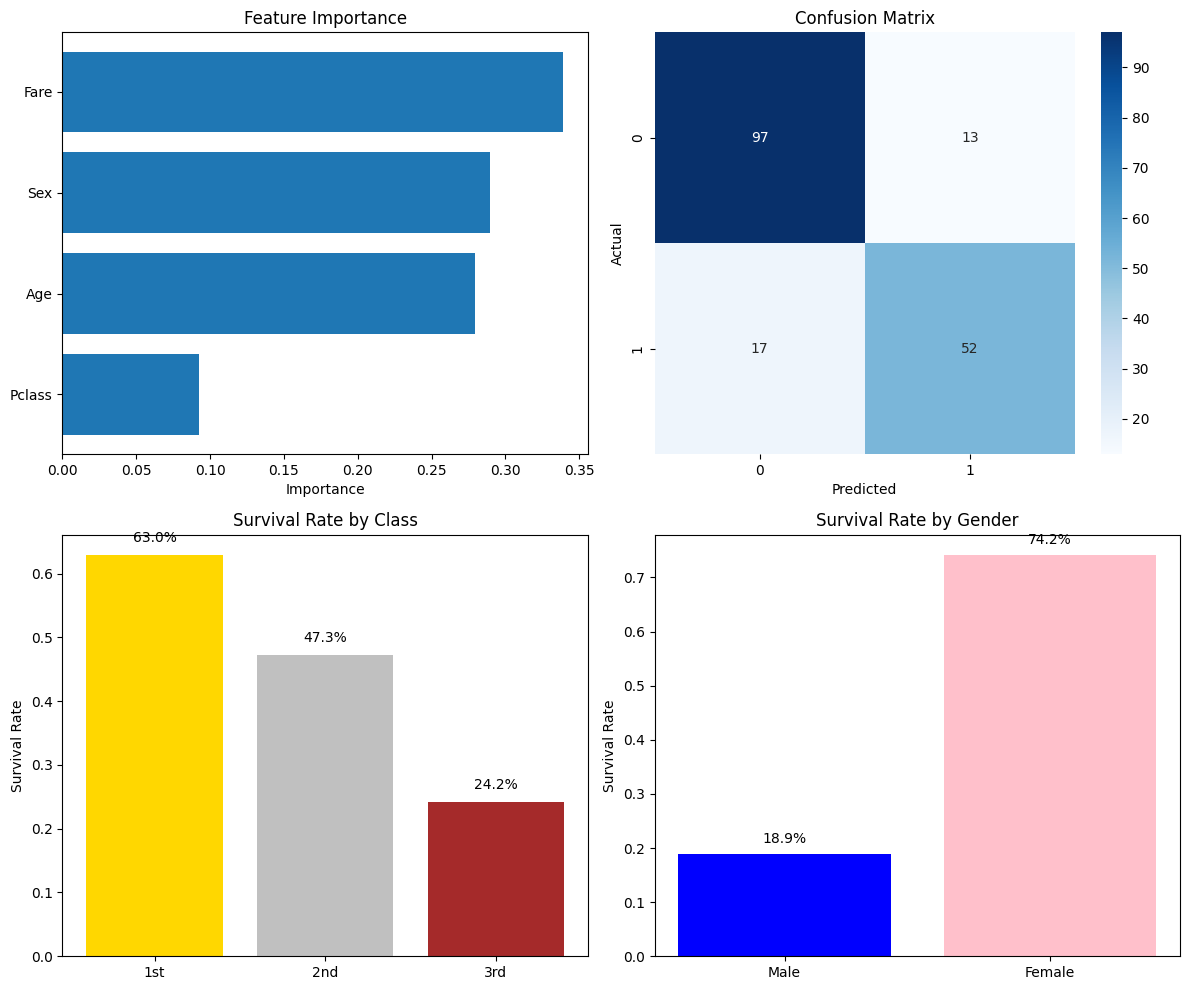


8. SUMMARY
----------------------------------------
Model: Random Forest Classifier
Features used: ['Pclass', 'Sex', 'Age', 'Fare']
Test Accuracy: 83.24%

Key Insights:
- Female survival: 74.2%
- Male survival: 18.9%
- 1st class survival: 63.0%
- 3rd class survival: 24.2%

TASK COMPLETED: Titanic Survival Classification


In [17]:
# ========== TITANIC SURVIVAL CLASSIFICATION ==========
# Task: Build ML model to predict passenger survival based on age, gender, ticket class, and fare

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("="*60)
print("TITANIC SURVIVAL CLASSIFICATION")
print("="*60)

# ========== 1. LOAD DATA ==========
print("\n1. LOADING DATA")
print("-"*40)

train = pd.read_csv('/kaggle/input/titanic/train.csv')
print(f"Training data loaded: {train.shape}")

# ========== 2. CLEAN AND PREPROCESS DATA ==========
print("\n2. DATA CLEANING AND PREPROCESSING")
print("-"*40)

# Handle missing values
train['Age'] = train['Age'].fillna(train['Age'].median())
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])

# Convert categorical to numerical
train['Sex'] = train['Sex'].map({'male': 0, 'female': 1})
train['Embarked'] = train['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

# Select features from task requirements
features = ['Pclass', 'Sex', 'Age', 'Fare']
X = train[features]
y = train['Survived']

print(f"Selected features: {features}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

# ========== 3. SPLIT DATA ==========
print("\n3. TRAIN-TEST SPLIT")
print("-"*40)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

# ========== 4. SCALE FEATURES ==========
print("\n4. FEATURE SCALING")
print("-"*40)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features scaled successfully")

# ========== 5. TRAIN CLASSIFICATION MODEL ==========
print("\n5. TRAINING MODEL")
print("-"*40)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)
print("Random Forest model trained successfully")

# ========== 6. EVALUATE PERFORMANCE ==========
print("\n6. MODEL EVALUATION")
print("-"*40)

# Predictions
y_pred = model.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# ========== 7. VISUALIZE RESULTS ==========
print("\n7. VISUALIZATIONS")
print("-"*40)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Feature importance
importances = model.feature_importances_
indices = np.argsort(importances)
feature_names = [features[i] for i in indices]
axes[0, 0].barh(range(len(indices)), importances[indices])
axes[0, 0].set_yticks(range(len(indices)))
axes[0, 0].set_yticklabels(feature_names)
axes[0, 0].set_xlabel('Importance')
axes[0, 0].set_title('Feature Importance')

# Plot 2: Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1])
axes[0, 1].set_title('Confusion Matrix')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

# Plot 3: Survival by class
survival_by_class = train.groupby('Pclass')['Survived'].mean()
axes[1, 0].bar(['1st', '2nd', '3rd'], survival_by_class.values, color=['gold', 'silver', 'brown'])
axes[1, 0].set_title('Survival Rate by Class')
axes[1, 0].set_ylabel('Survival Rate')
for i, v in enumerate(survival_by_class.values):
    axes[1, 0].text(i, v + 0.02, f'{v:.1%}', ha='center')

# Plot 4: Survival by gender
survival_by_gender = train.groupby('Sex')['Survived'].mean()
gender_labels = ['Male', 'Female'] if 0 in survival_by_gender.index else ['Female', 'Male']
axes[1, 1].bar(gender_labels, survival_by_gender.values, color=['blue', 'pink'])
axes[1, 1].set_title('Survival Rate by Gender')
axes[1, 1].set_ylabel('Survival Rate')
for i, v in enumerate(survival_by_gender.values):
    axes[1, 1].text(i, v + 0.02, f'{v:.1%}', ha='center')

plt.tight_layout()
plt.show()

# ========== 8. FINAL SUMMARY ==========
print("\n8. SUMMARY")
print("-"*40)
print(f"Model: Random Forest Classifier")
print(f"Features used: {features}")
print(f"Test Accuracy: {accuracy:.2%}")
print(f"\nKey Insights:")
print(f"- Female survival: {train[train['Sex'] == 1]['Survived'].mean():.1%}")
print(f"- Male survival: {train[train['Sex'] == 0]['Survived'].mean():.1%}")
print(f"- 1st class survival: {train[train['Pclass'] == 1]['Survived'].mean():.1%}")
print(f"- 3rd class survival: {train[train['Pclass'] == 3]['Survived'].mean():.1%}")

print("\n" + "="*60)
print("TASK COMPLETED: Titanic Survival Classification")
print("="*60)